# Task 2: Customer Segmentation Using Unsupervised Learning

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(200, 5)

First 5 Rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Dataset Information

In [3]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


### Observation

- Dataset contains 200 customer records and 5 columns.
- There are no missing values in the dataset.
- The dataset contains 4 numerical columns and 1 categorical column (Genre).
- The data is clean and ready for analysis.

## Statistical Summary

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Observation

- Average customer age is 38.85 years.
- Average annual income is 60.56 k$.
- Average spending score is 50.20.
- Youngest customer is 18 years old and oldest customer is 70 years old.
- Annual income ranges from 15 k$ to 137 k$.
- Spending score ranges from 1 to 99.

## Age Distribution

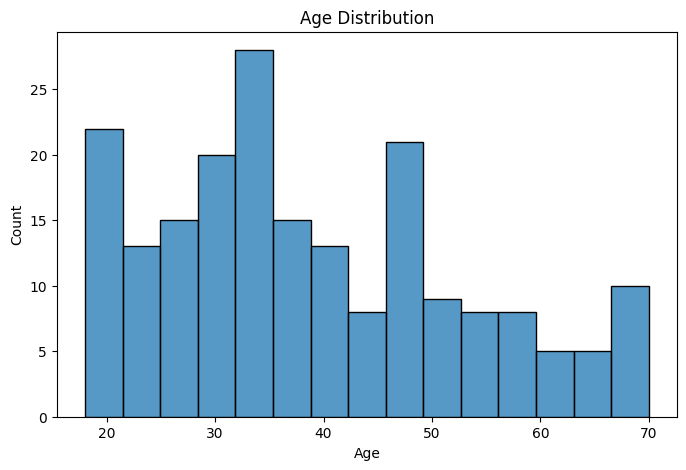

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

## Annual Income Distribution

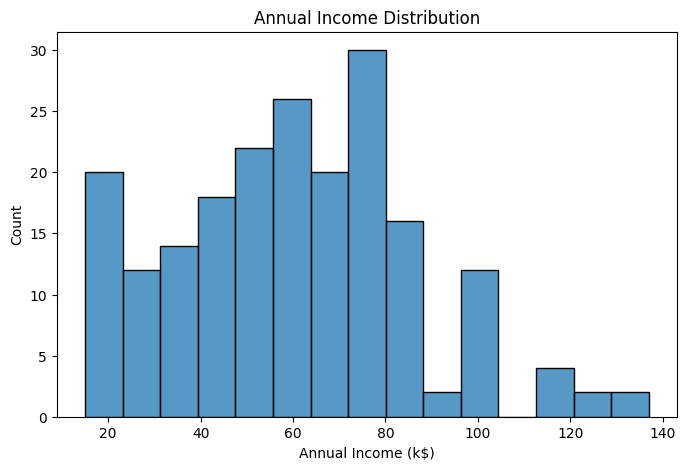

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=15)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Count")

plt.show()

### Observation

Most customers have annual incomes between 40k$ and 80k$.
The income distribution shows a mix of low, medium, and high-income customers.

## Spending Score Distribution

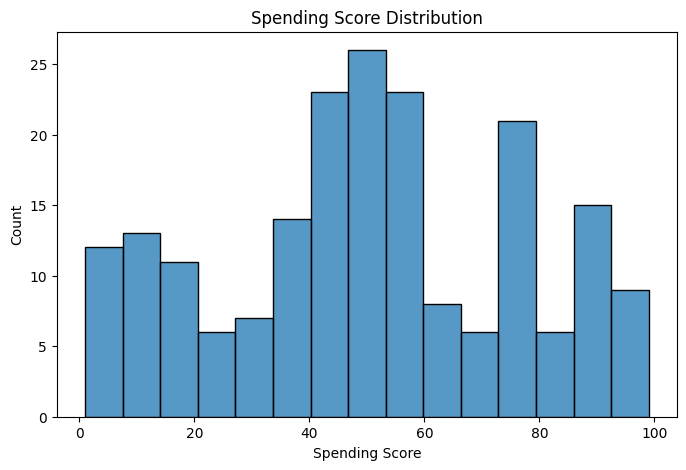

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=15)

plt.title("Spending Score Distribution")

plt.xlabel("Spending Score")

plt.ylabel("Count")

plt.show()

### Observation

Customers have spending scores ranging from 1 to 99.
Most customers are distributed across medium spending scores, with some customers showing very high and very low spending behavior.

## Gender Distribution

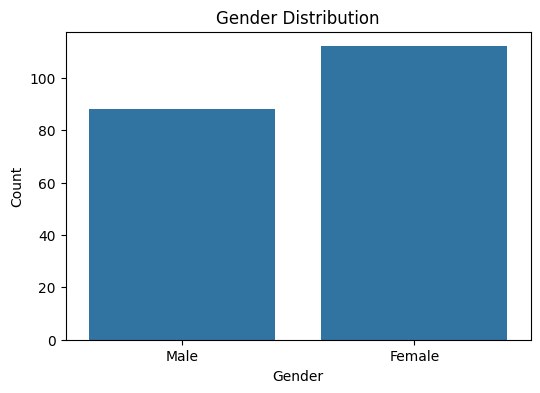

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="Genre", data=df)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

### Observation

The dataset contains both male and female customers.
This visualization helps understand the gender distribution of customers in the mall.

## Annual Income vs Spending Score

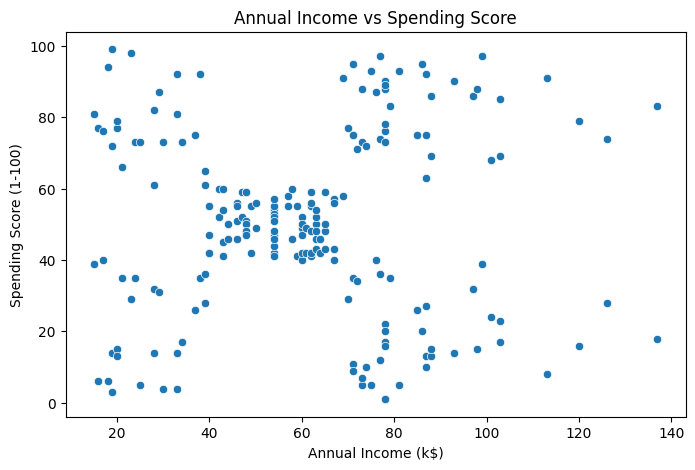

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.show()

### Observation

The scatter plot shows the relationship between annual income and spending score.

Some customers have high income and high spending scores.
Some customers have high income but low spending scores.
Some customers have low income and low spending scores.

This indicates that customers may naturally form different groups.

## EDA Summary

### Key Findings

- The dataset contains 200 customer records and 5 features.
- There are no missing values in the dataset.
- The average customer age is 38.85 years.
- The average annual income is 60.56 k$.
- The average spending score is 50.20.
- Both male and female customers are present in the dataset.
- Customers show different spending behaviors across income levels.
- The scatter plot suggests the presence of multiple customer groups.

# Part 2: K-Means Clustering

## Import K-Means

In [10]:
from sklearn.cluster import KMeans

print("KMeans imported successfully!")

KMeans imported successfully!


## Selecting Features

In [11]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


## Elbow Method

In [12]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28, 181363.59595959596, 106348.37306211119, 73679.78903948834, 44448.45544793371, 37233.81451071001, 30241.343617936585, 25036.417604033984, 21916.794789843727, 20072.07093940401]


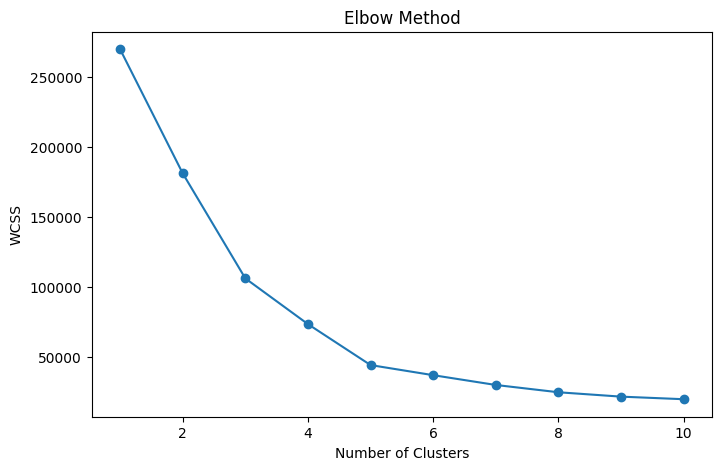

In [13]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

## Applying K-Means Clustering

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans[:10])

[4 2 4 2 4 2 4 2 4 2]


In [15]:
df["Cluster"] = y_kmeans

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Cluster Visualization

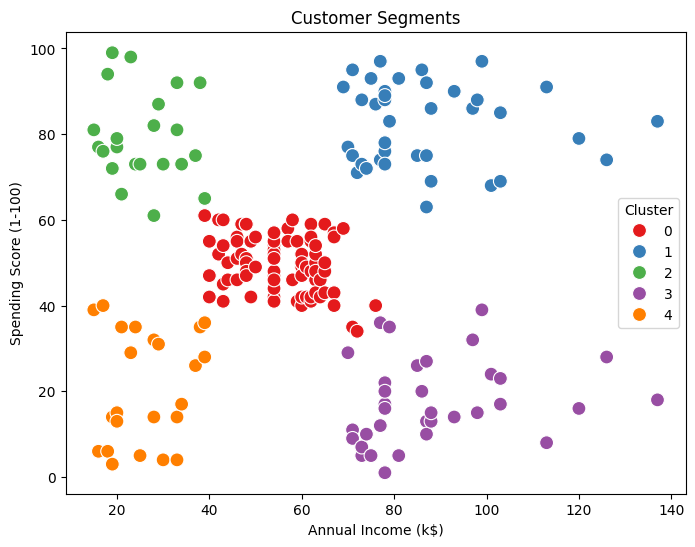

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=100
)

plt.title("Customer Segments")

plt.show()

## Business Insights

Cluster 0:
Medium Income, Medium Spending customers.

Cluster 1:
High Income, High Spending customers.
These are premium customers and should be targeted with loyalty programs.

Cluster 2:
Low Income, High Spending customers.
They spend actively despite lower income.

Cluster 3:
High Income, Low Spending customers.
These customers have potential and can be targeted through marketing campaigns.

Cluster 4:
Low Income, Low Spending customers.
They are less profitable compared to other groups.

## Conclusion

K-Means Clustering was applied to segment mall customers into 5 groups.

The Elbow Method identified 5 as the optimal number of clusters.

The analysis revealed different customer segments based on annual income and spending score, helping businesses create targeted marketing strategies and improve customer engagement.

## PCA Visualization

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca[:5])

[[-46.90357403   1.0992468 ]
 [-35.92438931  41.63882626]
 [-54.56484822 -31.01468908]
 [-36.00479787  37.51650477]
 [-44.7117087    1.54165656]]


In [18]:
pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])

pca_df["Cluster"] = y_kmeans

pca_df.head()

,PCA1,PCA2,Cluster
0,-46.903574,1.099247,4
1,-35.924389,41.638826,2
2,-54.564848,-31.014689,4
3,-36.004798,37.516505,2
4,-44.711709,1.541657,4


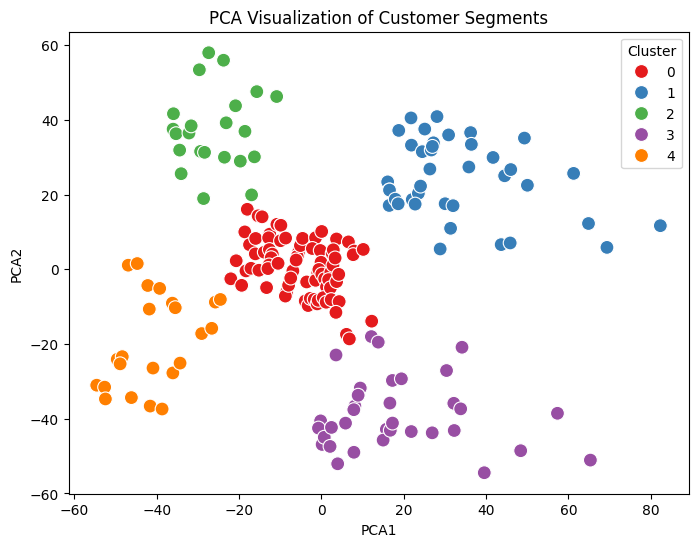

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    data=pca_df,
    s=100
)

plt.title("PCA Visualization of Customer Segments")

plt.show()

## PCA Visualization Insights

- PCA reduced the dataset into 2 principal components for visualization.
- The clusters are clearly separated, indicating that K-Means clustering performed effectively.
- Cluster 1 represents high-income, high-spending customers.
- Cluster 2 represents low-income, high-spending customers.
- Cluster 3 represents high-income, low-spending customers.
- Cluster 4 represents low-income, low-spending customers.
- Cluster 5 represents average customers with moderate income and spending behavior.

### Conclusion
The customer segmentation successfully identified different customer groups. Businesses can use these insights to design targeted marketing strategies, improve customer engagement, and increase sales.